# Problema Rainhas - EasyGA

In [27]:
!pip install EasyGA --no-deps

In [28]:
import EasyGA
import random

In [29]:
# Função objetivo: número de pares de rainhas não-atacadas
# nQueens: Número de rainhas
# Solução ótima: (nQueens x nQueens-1)/2


def fitnessFunction(solucao):
  solucao_list = solucao.gene_value_list
  melhorFitness = (len(solucao_list) * (len(solucao_list) - 1)) // 2 # // só a parte inteira
  # Contagem de pares de ataques
  h = 0
  # Verificar os ataques pela diagonal
  for i in range(0, len(solucao_list)):
    for j in range(i + 1, len(solucao_list)):
      if abs(i - j) == abs(solucao_list[i] - solucao_list[j]): # abs - valor absoluto
        h += 1
      # Verificação de ataques na mesma linha
      if abs(solucao_list[i] - solucao_list[j]) == 0:
        h += 1
  return melhorFitness - h

In [30]:
# Create the genetic algoritm
ga = EasyGA.GA()

In [31]:
# Problem size and optimal solution
sizeQueen = 10
optimalSolution = (sizeQueen * (sizeQueen-1)) // 2

In [32]:
# Chromossome params
ga.population_size = 20
ga.chromosome_length = sizeQueen
ga.generation_goal = 250

In [33]:
# Create random genes from 1 to 10
ga.gene_impl = lambda: random.randint(1, sizeQueen)


In [34]:
# Maximization of no attacks
ga.target_fitness = 'max'



In [35]:
# Set the fitness goal
ga.fitness_goal = optimalSolution

In [36]:
# Cadastra a funcao fitness
ga.fitness_function_impl = fitnessFunction

In [37]:
from EasyGA import mutation, crossover, parent

In [38]:
# Change selection, crossover and mutation
ga.crossover_individual_impl = crossover.Crossover.Individual.multi_point
ga.mutation_individual_impl = mutation.Mutation.Individual.Permutation.swap_genes
ga.parent_selection_impl = parent.Parent.Fitness.roulette

print(f'Optimal Solution: {optimalSolution}')
ga.evolve()
ga.print_generation()
ga.print_best_chromosome()


Optimal Solution: 45
Current Generation 	: 250
Best Chromosome 	: [4][10][1][6][9][3][8][3][2][10]
Best Fitness    	: 42


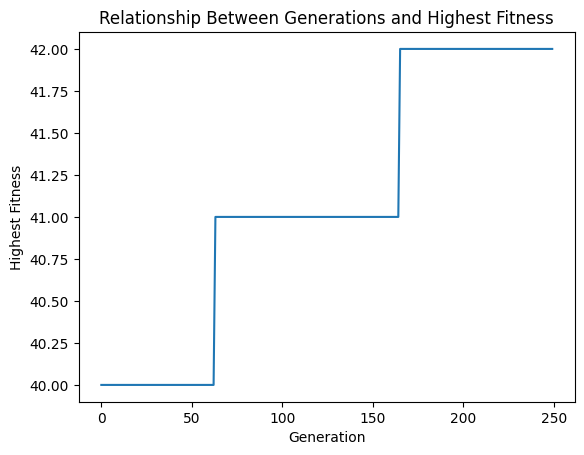

In [39]:
# Mostra a curva de convergência
ga.graph.highest_value_chromosome()
ga.graph.show()